# Project: Investigate a Dataset - FBI NICS Firearm Background Check Data

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 
The data comes from the FBI's National Instant Criminal Background Check System. The NICS is used by to determine whether a prospective buyer is eligible to buy firearms or explosives.
Gun shops call into this system to ensure that each customer does not have a criminal record or isn’t otherwise ineligible to make a purchase.
The data has been supplemented with state level data from census.gov(opens in a new tab).
The **NICS data** contains the number of firearm checks by month, state, and type.
The **U.S. census data** contains several variables at the state level. Most variables just have one data point per state (2016), but a few have data for more than one year. The dataset contains one table with 27 columns and 1,2487 rows. The columns are the following: month,state,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,prepawn_long_gun,prepawn_other,redemption_handgun,redemption_long_gun,redemption_other,returned_handgun,returned_long_gun,returned_other,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals.

The dataset is available in CSV format can be downloaded -> [FBI Gun Data](https://video.udacity-data.com/topher/2025/September/68c92f0b_gun_data/gun_data.csv).


### Question(s) for Analysis
>**Tip**: Clearly state one or more questions that you plan on exploring over the course of the report. You will address these questions in the **data analysis** and **conclusion** sections. Try to build your report around the analysis of at least one dependent variable and three independent variables. If you're not sure what questions to ask, then make sure you familiarize yourself with the dataset, its variables and the dataset context for ideas of what to explore.
- Which states have the highest and lowest number of firearm background checks?
- What are the trends in firearm background checks over time?
- How do these trends vary by state and by type of firearm?
- Are there any correlations between the number of background checks and state-level demographic or socioeconomic factors?

> **Tip**: Once you start coding, use NumPy arrays, Pandas Series, and DataFrames where appropriate rather than Python lists and dictionaries. Also, **use good coding practices**, such as, define and use functions to avoid repetitive code. Use appropriate comments within the code cells, explanation in the mark-down cells, and meaningful variable names. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# While optional for current notebooks, if you are having trouble with visualizations,
#   remember to include a 'magic word' so that your visualizations are plotted
#   inline with the notebook. See this page for more:
#   http://ipython.readthedocs.io/en/stable/interactive/magics.html


<a id='wrangling'></a>
## Data Wrangling

> **Tip**: In this section of the report, you will load in the data, check for cleanliness, and then trim and clean your dataset for analysis. Make sure that you **document your data cleaning steps in mark-down cells precisely and justify your cleaning decisions.**


### General Properties
> **Tip**: You should _not_ perform too many operations in each cell. Create cells freely to explore your data. One option that you can take with this project is to do a lot of explorations initially. This does not have to be organized, but make sure you use enough comments to understand the purpose of each code cell. Then, after you're done with your analysis, trim the excess and organize your steps so that you have a flowing, cohesive report.

In [2]:
# Load your data and print out a few lines. What is the size of your dataframe?
df = pd.read_csv('gun_data.csv')
df.head()
#   Perform operations to inspect data types and look for instances of missing
#   or possibly errant data. There are at least 4 - 6 methods you can call on your
#   dataframe to obtain this information.



,month,state,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,...,returned_other,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals
0,2017-09,Alabama,16717.0,0.0,5734.0,6320.0,221.0,317,0.0,15.0,...,0.0,0.0,0.0,9.0,16.0,3.0,0.0,0.0,3.0,32019
1,2017-09,Alaska,209.0,2.0,2320.0,2930.0,219.0,160,0.0,5.0,...,0.0,0.0,0.0,17.0,24.0,1.0,0.0,0.0,0.0,6303
2,2017-09,Arizona,5069.0,382.0,11063.0,7946.0,920.0,631,0.0,13.0,...,0.0,0.0,0.0,38.0,12.0,2.0,0.0,0.0,0.0,28394
3,2017-09,Arkansas,2935.0,632.0,4347.0,6063.0,165.0,366,51.0,12.0,...,0.0,0.0,0.0,13.0,23.0,0.0,0.0,2.0,1.0,17747
4,2017-09,California,57839.0,0.0,37165.0,24581.0,2984.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,123506


In [3]:
# shape of the dataframe
df.shape

(12485, 27)

In [4]:
# data types of each column
df.dtypes

month                            str
state                            str
permit                       float64
permit_recheck               float64
handgun                      float64
long_gun                     float64
other                        float64
multiple                       int64
admin                        float64
prepawn_handgun              float64
prepawn_long_gun             float64
prepawn_other                float64
redemption_handgun           float64
redemption_long_gun          float64
redemption_other             float64
returned_handgun             float64
returned_long_gun            float64
returned_other               float64
rentals_handgun              float64
rentals_long_gun             float64
private_sale_handgun         float64
private_sale_long_gun        float64
private_sale_other           float64
return_to_seller_handgun     float64
return_to_seller_long_gun    float64
return_to_seller_other       float64
totals                         int64
d

In [5]:
# look at the summary statistics of the dataframe
df.describe()

,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,prepawn_long_gun,prepawn_other,...,returned_other,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals
count,12461.000000,1100.000000,12465.000000,12466.000000,5500.000000,12485.000000,12462.000000,10542.000000,10540.000000,5115.000000,...,1815.000000,990.000000,825.000000,2750.000000,2750.000000,2750.000000,2475.000000,2750.000000,2255.000000,12485.000000
mean,6413.629404,1165.956364,5940.881107,7810.847585,360.471636,268.603364,58.898090,4.828021,7.834156,0.165591,...,1.027548,0.076768,0.087273,14.936000,11.602909,1.030182,0.402020,0.441818,0.105987,21595.725911
std,23752.338269,9224.200609,8618.584060,9309.846140,1349.478273,783.185073,604.814818,10.907756,16.468028,1.057105,...,4.386296,0.634503,0.671649,71.216021,54.253090,4.467843,1.446568,1.528223,0.427363,32591.418387
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,865.000000,2078.250000,17.000000,15.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4638.000000
50%,518.000000,0.000000,3059.000000,5122.000000,121.000000,125.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12399.000000
75%,4272.000000,0.000000,7280.000000,10380.750000,354.000000,301.000000,0.000000,5.000000,8.000000,0.000000,...,0.000000,0.000000,0.000000,2.000000,4.000000,0.000000,0.000000,0.000000,0.000000,25453.000000
max,522188.000000,116681.000000,107224.000000,108058.000000,77929.000000,38907.000000,28083.000000,164.000000,269.000000,49.000000,...,64.000000,12.000000,12.000000,1017.000000,777.000000,71.000000,28.000000,17.000000,4.000000,541978.000000


In [6]:
# look at the number of missing values in each column
df.isnull().sum()

month                            0
state                            0
permit                          24
permit_recheck               11385
handgun                         20
long_gun                        19
other                         6985
multiple                         0
admin                           23
prepawn_handgun               1943
prepawn_long_gun              1945
prepawn_other                 7370
redemption_handgun            1940
redemption_long_gun           1941
redemption_other              7370
returned_handgun             10285
returned_long_gun            10340
returned_other               10670
rentals_handgun              11495
rentals_long_gun             11660
private_sale_handgun          9735
private_sale_long_gun         9735
private_sale_other            9735
return_to_seller_handgun     10010
return_to_seller_long_gun     9735
return_to_seller_other       10230
totals                           0
dtype: int64

In [7]:
print("\n── Missing values per column ──")
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
        .query("missing_count > 0")
        .sort_values("missing_%", ascending=False))


── Missing values per column ──
                           missing_count  missing_%
rentals_long_gun                   11660      93.39
rentals_handgun                    11495      92.07
permit_recheck                     11385      91.19
returned_other                     10670      85.46
returned_long_gun                  10340      82.82
returned_handgun                   10285      82.38
return_to_seller_other             10230      81.94
return_to_seller_handgun           10010      80.18
return_to_seller_long_gun           9735      77.97
private_sale_other                  9735      77.97
private_sale_long_gun               9735      77.97
private_sale_handgun                9735      77.97
redemption_other                    7370      59.03
prepawn_other                       7370      59.03
other                               6985      55.95
prepawn_long_gun                    1945      15.58
prepawn_handgun                     1943      15.56
redemption_long_gun            

In [8]:
# look at the duplicate rows in the dataframe
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
12480    False
12481    False
12482    False
12483    False
12484    False
Length: 12485, dtype: bool

In [9]:
# Duplicated value counts
print("\nDuplicate rows:", df.duplicated().sum())



Duplicate rows: 0



### Data Cleaning
> **Tip**: Make sure that you keep your reader informed on the steps that you are taking in your investigation. Follow every code cell, or every set of related code cells, with a markdown cell to describe to the reader what was found in the preceding cell(s). Try to make it so that the reader can then understand what they will be seeing in the following cell(s).


In [10]:
# ── PARSE DATE ─────────────────────────────────────────────────────────────
# 'month' is formatted as YYYY-MM — parse and extract useful parts
df["month"] = pd.to_datetime(df["month"], format="%Y-%m")
df["year"]  = df["month"].dt.year
df["month_num"] = df["month"].dt.month

print("\nDate range:", df["month"].min(), "→", df["month"].max())
df.head()


Date range: 1998-11-01 00:00:00 → 2017-09-01 00:00:00


,month,state,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,...,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals,year,month_num
0,2017-09-01,Alabama,16717.0,0.0,5734.0,6320.0,221.0,317,0.0,15.0,...,0.0,9.0,16.0,3.0,0.0,0.0,3.0,32019,2017,9
1,2017-09-01,Alaska,209.0,2.0,2320.0,2930.0,219.0,160,0.0,5.0,...,0.0,17.0,24.0,1.0,0.0,0.0,0.0,6303,2017,9
2,2017-09-01,Arizona,5069.0,382.0,11063.0,7946.0,920.0,631,0.0,13.0,...,0.0,38.0,12.0,2.0,0.0,0.0,0.0,28394,2017,9
3,2017-09-01,Arkansas,2935.0,632.0,4347.0,6063.0,165.0,366,51.0,12.0,...,0.0,13.0,23.0,0.0,0.0,2.0,1.0,17747,2017,9
4,2017-09-01,California,57839.0,0.0,37165.0,24581.0,2984.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,123506,2017,9


In [11]:
# ── NUMERIC COLUMNS ────────────────────────────────────────────────────────
# All columns except month/state are counts — coerce to numeric safely
count_cols = df.columns.difference(["month", "state", "year", "month_num",
                                     "is_territory"])

for col in count_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [12]:
# ── HANDLE MISSING NUMERIC VALUES ─────────────────────────────────────────
# Early years (1998-2003) have many NaN columns — fill with 0
df[count_cols] = df[count_cols].fillna(0).astype(int)

In [13]:
# ── VALIDATE TOTALS ────────────────────────────────────────────────────────
# The 'totals' column should equal the sum of all check-type columns
check_type_cols = [c for c in count_cols if c != "totals"]
df["computed_total"] = df[check_type_cols].sum(axis=1)
mismatch = df[df["totals"] != df["computed_total"]]

print(f"\nRows where 'totals' ≠ sum of parts: {len(mismatch)}")
if not mismatch.empty:
    print(mismatch[["month", "state", "totals", "computed_total"]].head(10))



Rows where 'totals' ≠ sum of parts: 0


In [14]:
# ── CHECK FOR NEGATIVE VALUES (invalid counts) ────────────────────────────
neg_check = {col: (df[col] < 0).sum() for col in count_cols}
neg_cols = {k: v for k, v in neg_check.items() if v > 0}
if neg_cols:
    print("\nColumns with negative values:", neg_cols)
else:
    print("\nNo negative values found ✓")


No negative values found ✓


In [15]:
# ── CHECK UNIQUENESS OF (month, state) KEY ───────────────────────────────
dupes = df[df.duplicated(subset=["month", "state"], keep=False)]
print(f"\nDuplicate (month, state) pairs: {len(dupes)}")
if not dupes.empty:
    print(dupes[["month", "state"]].head())


Duplicate (month, state) pairs: 0


In [16]:
print("Final shape:", df.shape)

Final shape: (12485, 30)


<a id='eda'></a>
## Exploratory Data Analysis

> **Tip**: Now that you've trimmed and cleaned your data, you're ready to move on to exploration. **Compute statistics** and **create visualizations** with the goal of addressing the research questions that you posed in the Introduction section. You should compute the relevant statistics throughout the analysis when an inference is made about the data. Note that at least two or more kinds of plots should be created as part of the exploration, and you must  compare and show trends in the varied visualizations. Remember to utilize the visualizations that the pandas library already has available.



> **Tip**: Investigate the stated question(s) from multiple angles. It is recommended that you be systematic with your approach. Look at one variable at a time, and then follow it up by looking at relationships between variables. You should explore at least three variables in relation to the primary question. This can be an exploratory relationship between three variables of interest, or looking at how two independent variables relate to a single dependent variable of interest. Lastly, you  should perform both single-variable (1d) and multiple-variable (2d) explorations.


### Research Question 1 (Replace this header name!)

In [17]:
def get_state_totals(df, value_col="totals"):
    """Return total checks by state, descending."""
    return df.groupby("state")[value_col].sum().sort_values(ascending=False)


In [30]:
def plot_bar(series, kind="bar", title="", color=None, ylabel="Total Checks", figsize=(10,4), alpha=0):
    ax = series.plot(kind=kind, figsize=figsize, title=title, color=color)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

In [31]:
def monthly_totals(df, date_col="month", value_col="totals"):
    """Return monthly total checks over time."""
    return df.groupby(date_col)[value_col].sum()


In [32]:
def top_n_states_trend(df, state_totals, n=5, date_col="month", value_col="totals"):
    top_states = state_totals.head(n).index
    return (
        df[df["state"].isin(top_states)]
        .pivot_table(index=date_col, columns="state", values=value_col, aggfunc="sum")
    )

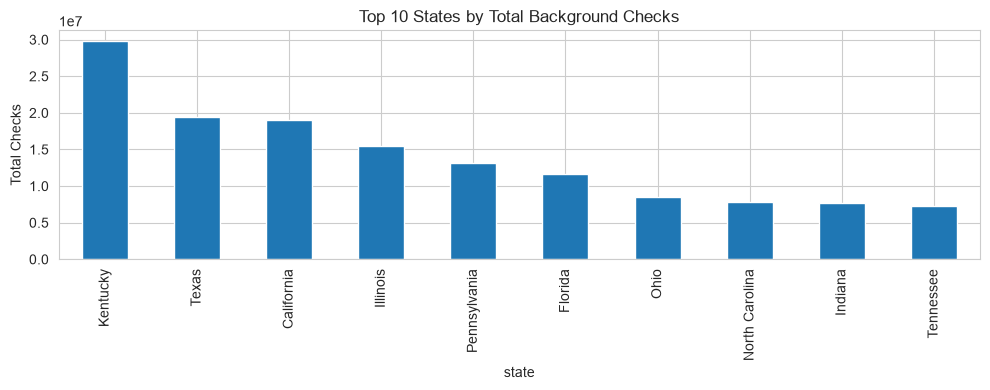

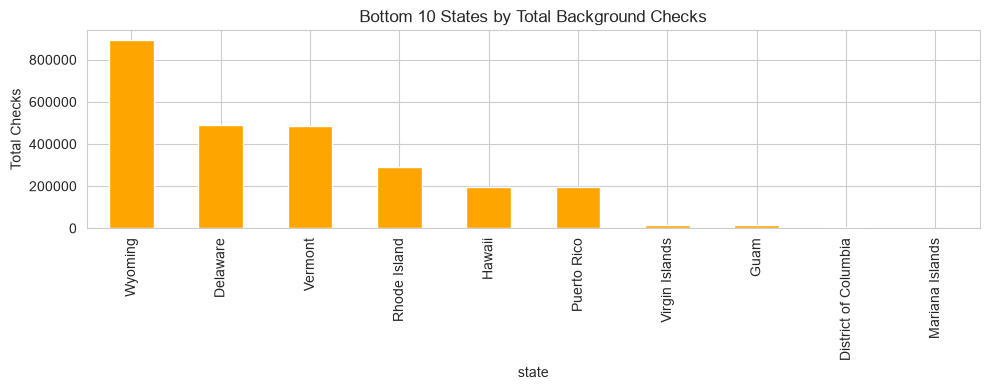

In [33]:
# Use this, and more code cells, to explore your data. Don't forget to add
#   Markdown cells to document your observations and findings.

# 1. Which states have the highest and lowest number of firearm background checks?
df["month"] = pd.to_datetime(df["month"])
state_totals = get_state_totals(df)

plot_bar(state_totals.head(10), title="Top 10 States by Total Background Checks")
plot_bar(state_totals.tail(10), title="Bottom 10 States by Total Background Checks", color="orange")

# Findings from above visualizations
States in the top 10 contribute a large share of total checks, while the bottom 10 are much lower. This suggests strong geographic concentration.


Overall monthly trend summary:
count    2.270000e+02
mean     1.187765e+06
std      5.677207e+05
min      2.117600e+04
25%      7.276435e+05
50%      1.023080e+06
75%      1.516774e+06
max      3.308199e+06
Name: totals, dtype: float64


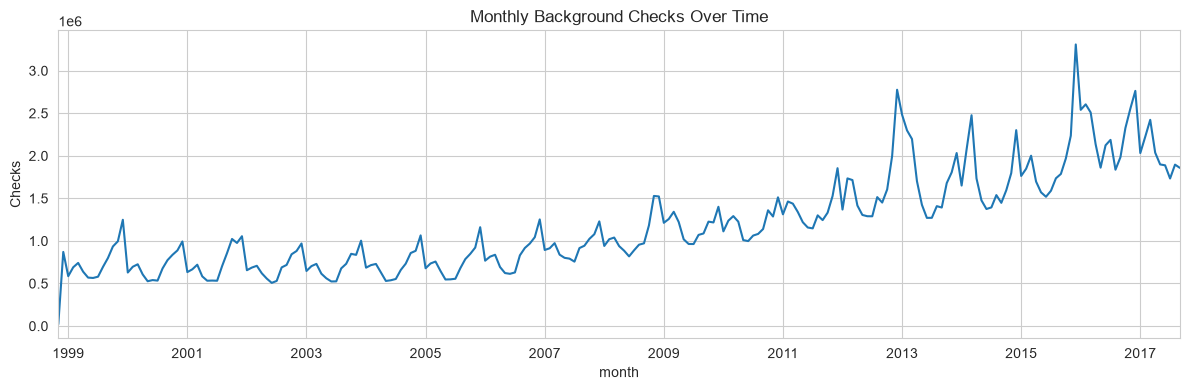

In [34]:
# 2. What are the trends in firearm background checks over time?
monthly_total = monthly_totals(df)
print("Overall monthly trend summary:")
print(monthly_total.describe())

plot_bar(monthly_total, kind="line", title="Monthly Background Checks Over Time", ylabel="Checks", figsize=(12,4))

 Findings from above visualizations:

 The overall trend shows a general increase in background checks over time, with some seasonal fluctuations. There are noticeable peaks and troughs, which may correspond to specific events or policy changes.

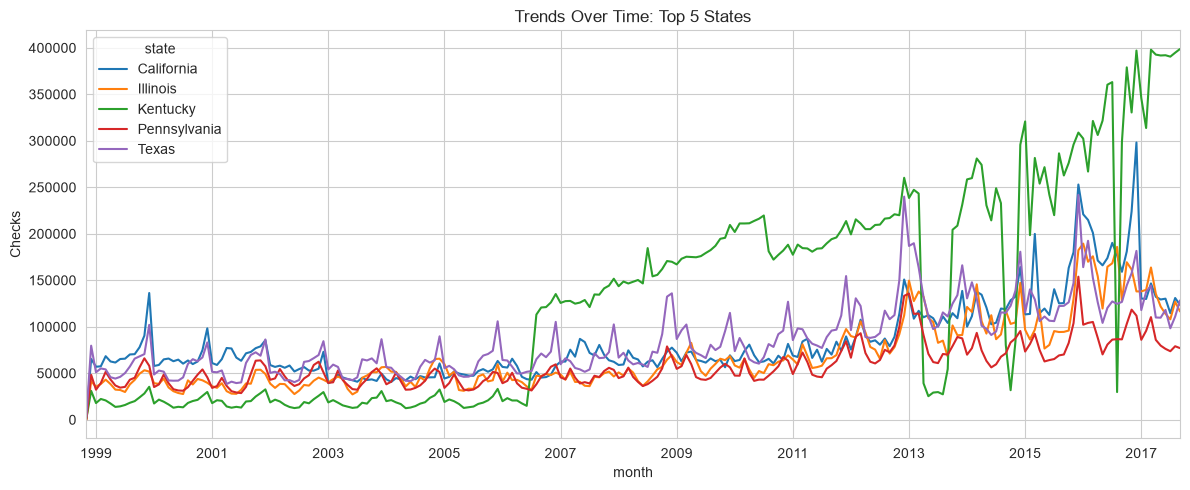

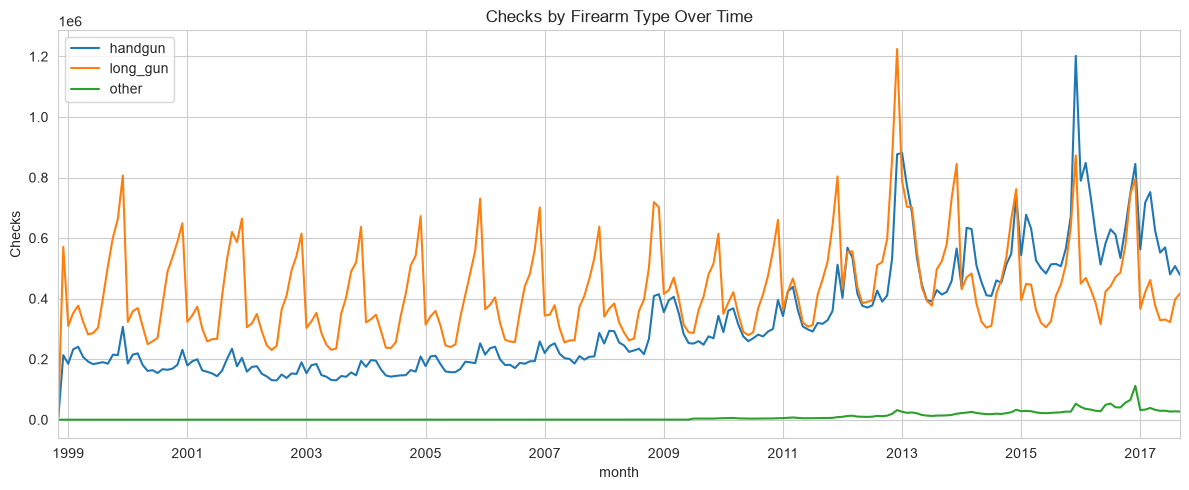

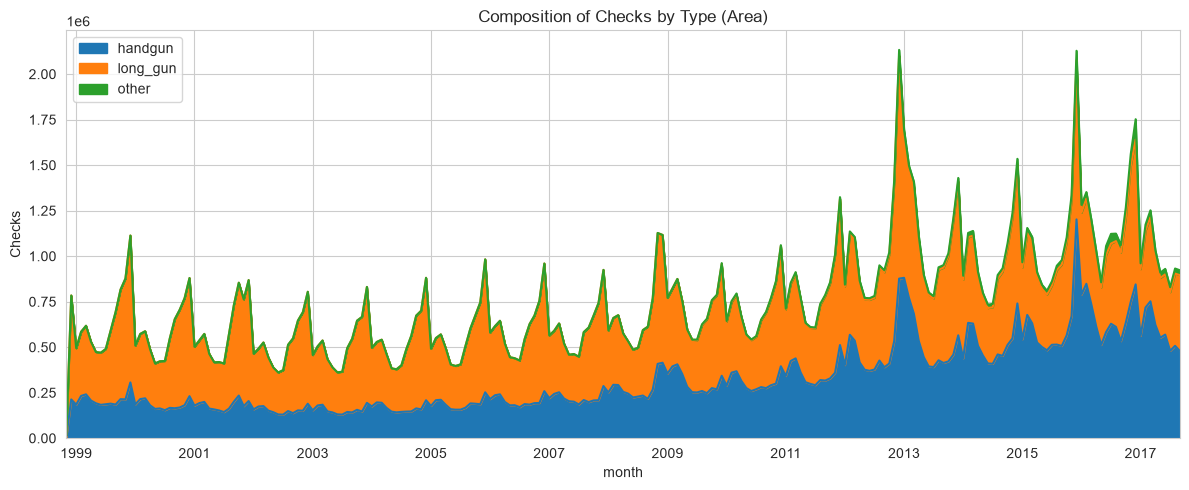

In [35]:
# Question 3. How do these trends vary by state and by type of firearm?
# Top 5 states overall
top5_states = top_n_states_trend(df, state_totals, n=5).columns.tolist()

# --- By state (2D: month x state -> totals)
top5_trend = (
    df[df["state"].isin(top5_states)]
    .pivot_table(index="month", columns="state", values="totals", aggfunc="sum")
)

plot_bar(top5_trend, kind="line", title="Trends Over Time: Top 5 States", ylabel="Checks", figsize=(12,5))

# --- By firearm type (handgun vs long_gun)
type_monthly = df.groupby("month")[["handgun", "long_gun", "other"]].sum()
plot_bar(type_monthly, kind="line", title="Checks by Firearm Type Over Time", ylabel="Checks", figsize=(12,5))


# Area chart for composition
plot_bar(type_monthly, kind="area", title="Composition of Checks by Type (Area)", ylabel="Checks", figsize=(12,5), alpha=0.6)


Findings from above visualizations:

The trends vary significantly by state, with some states showing more pronounced increases than others. The composition of checks by firearm type also shows that handguns consistently account for the majority of checks, followed by long guns and other types. The area chart highlights the relative proportions of each type over time, with handguns dominating the total checks.

<a id='conclusions'></a>
## Conclusions

> **Tip**: Finally, summarize your findings and the results that have been performed in relation to the question(s) provided at the beginning of the analysis. Summarize the results accurately, and point out where additional research can be done or where additional information could be useful.

> **Tip**: Make sure that you are clear with regards to the limitations of your exploration. You should have at least 1 limitation explained clearly. 

> **Tip**: If you haven't done any statistical tests, do not imply any statistical conclusions. And make sure you avoid implying causation from correlation!

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the rubric (found on the project submission page at the end of the lesson). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.

## Submitting your Project 

> **Tip**: Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should see output that starts with `NbConvertApp] Converting notebook`, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> **Tip**: Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> **Tip**: Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations!

## Conclusions
This analysis examined FBI NICS firearm background check data to answer three questions: state-level totals, overall time trends, and variation by state and firearm type.

Overall, background checks are not evenly distributed across states. A small set of states accounts for much higher total check volumes, while several states remain consistently low. This indicates strong geographic concentration in check activity.

Across time, monthly background checks show a clear long-term increase with noticeable fluctuations. The line plots suggest that activity changes over different periods rather than remaining stable year to year.

When broken down further, trends vary by state and by firearm type. The top states show larger and more variable monthly patterns than others. By firearm type, handgun checks make up the largest share over most of the timeline, with long-gun checks generally second and other checks much smaller. The area plot supports this composition pattern over time.

In [ ]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb